# LSTM Based Regression for Stock Price Prediction

### Group Members:
- Aditya Rao Ghodke
- Arvinder Singh Mundra
- Dharma Pokhrel

In [1]:
## Importing all required libraries

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import random
import os
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

In [2]:
# Defining seed

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"All random seeds fixed to {SEED} for full reproducibility.")

All random seeds fixed to 42 for full reproducibility.


In [3]:
# Download stock data

ticker = "AAPL"
start_date = "2010-01-01"
end_date = "2026-02-25"

data = yf.download(ticker, start=start_date, end=end_date, progress=False)
df = data.reset_index()[["Date", "Close"]]
df['Date'] = pd.to_datetime(df['Date'])
df.index = df.pop('Date')

df

Price,Close
Ticker,AAPL
Date,
2010-01-04,6.412384
2010-01-05,6.423470
2010-01-06,6.321296
2010-01-07,6.309610
2010-01-08,6.351558
...,...
2026-02-18,264.350006
2026-02-19,260.579987


In [4]:
df.to_csv("AAPL_closing_prices.csv")
print("Dataset saved to AAPL_closing_prices.csv")
print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print("No SQL/NoSQL database required — yfinance returns data directly as a pandas DataFrame.")
print("No JSON or XML parsing was necessary for this dataset.")

Dataset saved to AAPL_closing_prices.csv
Shape: (4060, 1)
Date range: 2010-01-04 00:00:00 to 2026-02-24 00:00:00
No SQL/NoSQL database required — yfinance returns data directly as a pandas DataFrame.
No JSON or XML parsing was necessary for this dataset.


In [5]:
# Check missing values

print("Missing values:\n", df.isnull().sum())

Missing values:
 Price  Ticker
Close  AAPL      0
dtype: int64


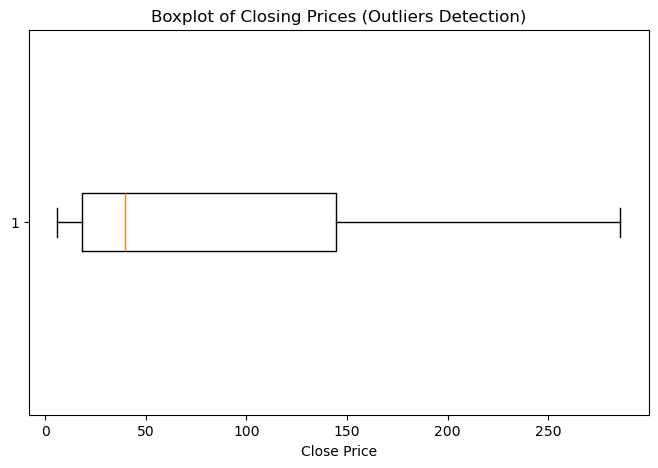

In [6]:
# Checking Outliers

plt.figure(figsize=(8, 5))
plt.boxplot(df['Close'], vert=False)
plt.title("Boxplot of Closing Prices (Outliers Detection)")
plt.xlabel("Close Price")
plt.show()

In [7]:
# Checking for basic stats for the data

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nSummary Statistics:\n", df.describe())

Shape: (4060, 1)

Data Types:
 Price  Ticker
Close  AAPL      float64
dtype: object

Summary Statistics:
 Price         Close
Ticker         AAPL
count   4060.000000
mean      79.079240
std       76.621780
min        5.754396
25%       18.348835
50%       39.535427
75%      144.310425
max      285.922455


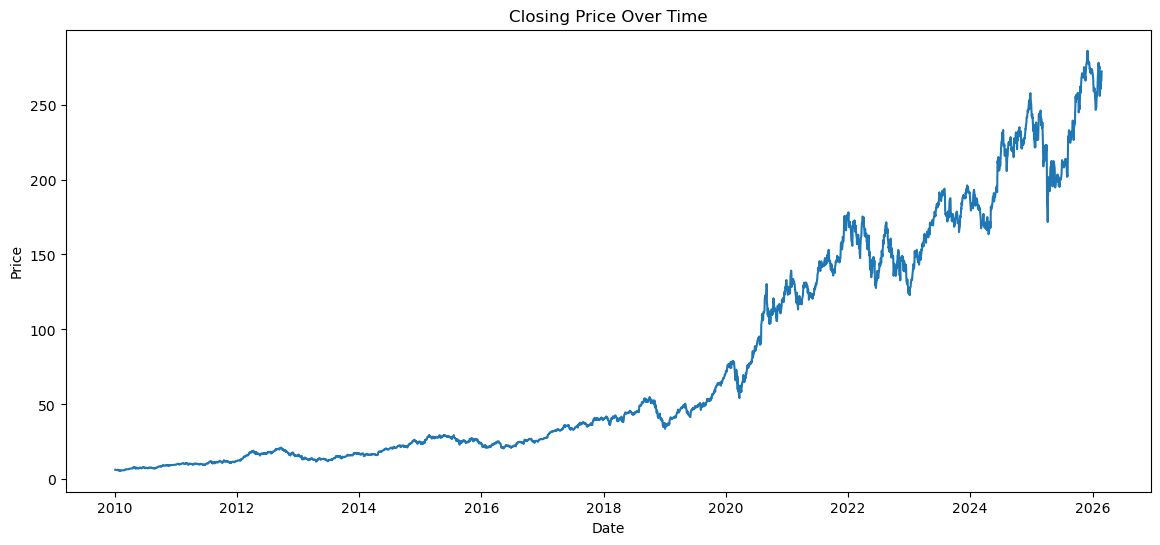

In [8]:
# Plotting the "Close Price Graph"

plt.figure(figsize=(14,6))
plt.plot(df.index, df['Close'])
plt.title("Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

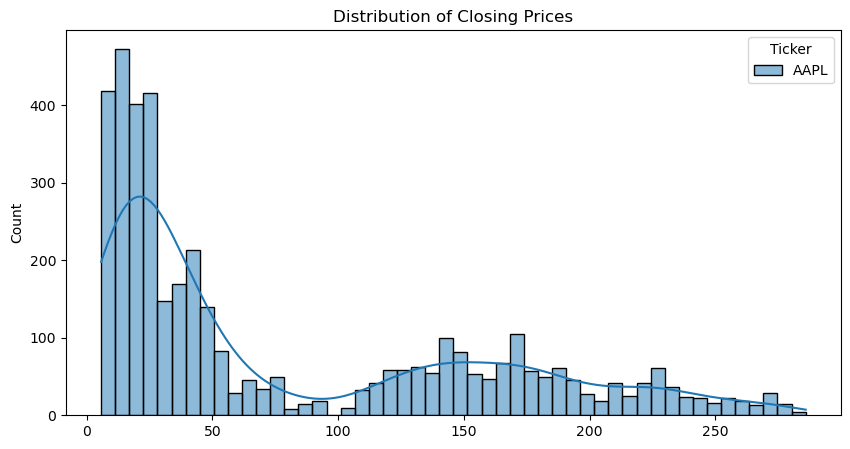

In [9]:
plt.figure(figsize=(10,5))
sns.histplot(df['Close'], bins=50, kde=True)
plt.title("Distribution of Closing Prices")
plt.show()

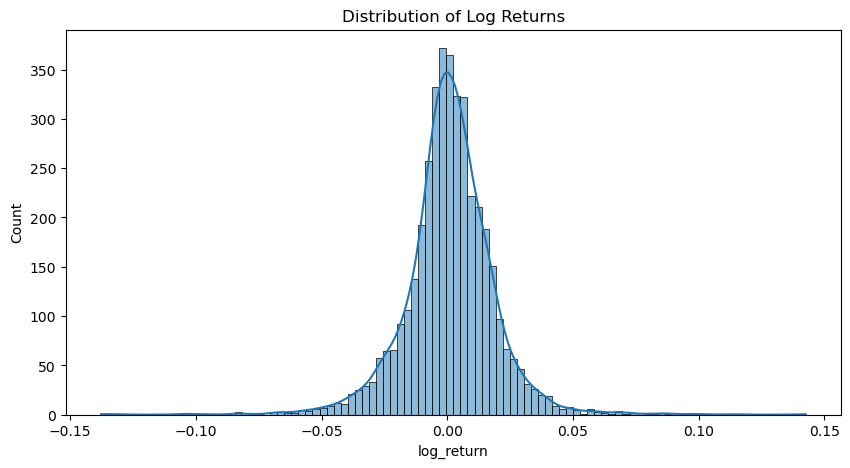

In [10]:
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
df = df.dropna()

plt.figure(figsize=(10,5))
sns.histplot(df['log_return'], bins=100, kde=True)
plt.title("Distribution of Log Returns")
plt.show()


In [11]:
# Formal Augmented Dickey-Fuller (ADF) Stationarity Test

# Test on raw Close price
adf_price = adfuller(df['Close'].dropna())
print("=== ADF Test: Raw Close Price ===")
print(f"  ADF Statistic : {adf_price[0]:.4f}")
print(f"  p-value       : {adf_price[1]:.4f}")
print(f"  Conclusion    : {'Non-stationary (fail to reject H0)' if adf_price[1] > 0.05 else 'Stationary (reject H0)'}")

# Test on log returns
adf_returns = adfuller(df['log_return'].dropna())
print("\n=== ADF Test: Log Returns ===")
print(f"  ADF Statistic : {adf_returns[0]:.4f}")
print(f"  p-value       : {adf_returns[1]:.4f}")
print(f"  Conclusion    : {'Non-stationary (fail to reject H0)' if adf_returns[1] > 0.05 else 'Stationary (reject H0)'}")

=== ADF Test: Raw Close Price ===
  ADF Statistic : 1.2059
  p-value       : 0.9960
  Conclusion    : Non-stationary (fail to reject H0)

=== ADF Test: Log Returns ===
  ADF Statistic : -21.5494
  p-value       : 0.0000
  Conclusion    : Stationary (reject H0)


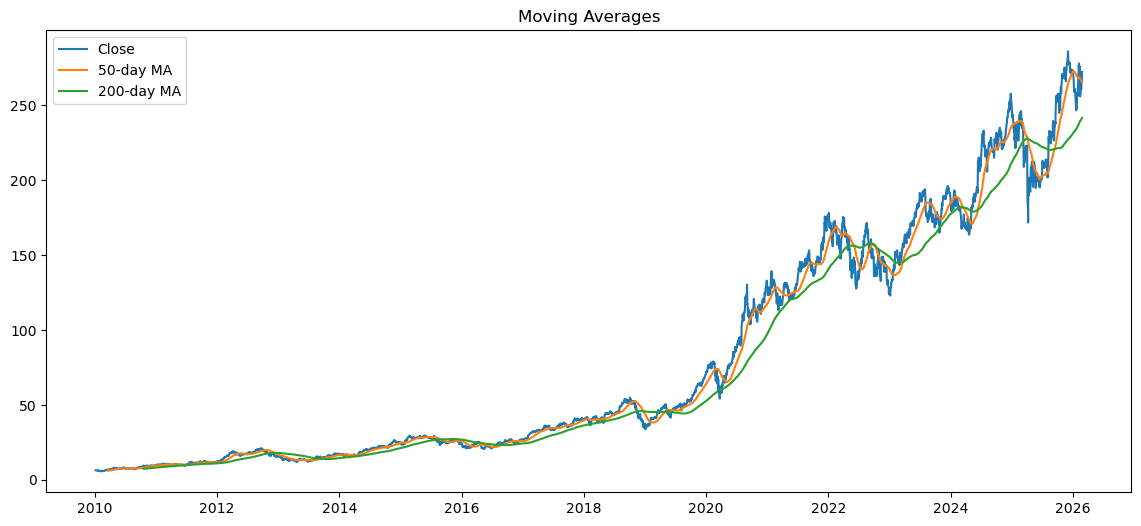

In [12]:
# Moving Average Plot

df = df.copy()

df['MA_50'] = df['Close'].rolling(50).mean()
df['MA_200'] = df['Close'].rolling(200).mean()

plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Close')
plt.plot(df['MA_50'], label='50-day MA')
plt.plot(df['MA_200'], label='200-day MA')
plt.legend()
plt.title("Moving Averages")
plt.show()

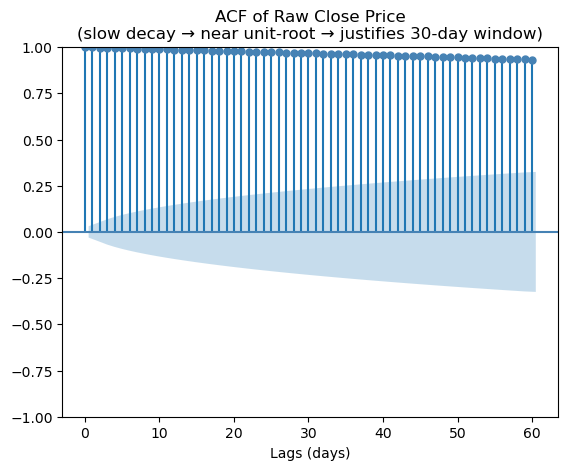

In [13]:
# ACF of raw Close price

plot_acf(df['Close'].dropna(), lags=60, color='steelblue')
plt.title("ACF of Raw Close Price\n(slow decay → near unit-root → justifies 30-day window)")
plt.xlabel("Lags (days)")
plt.show()

In [14]:
# Create sliding windows

def df_to_windowed_np(df, n=30):
    close_values = df['Close'].to_numpy().flatten()
    X = np.lib.stride_tricks.sliding_window_view(close_values, window_shape=n+1)
    X_values = X[:, :-1]
    Y_values = X[:, -1]
    dates = df.index[n:]
    return dates, X_values, Y_values

sequence_length = 30
dates, X, y = df_to_windowed_np(df, n=sequence_length)

X.shape, y.shape

((4029, 30), (4029,))

In [15]:
# Scaling the data

q_80 = int(len(dates) * 0.8)
q_90 = int(len(dates) * 0.9)

X_train, y_train = X[:q_80], y[:q_80]
X_val, y_val     = X[q_80:q_90], y[q_80:q_90]
X_test, y_test   = X[q_90:], y[q_90:]

dates_train, dates_val, dates_test = dates[:q_80], dates[q_80:q_90], dates[q_90:]

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = scaler_X.fit_transform(X_train.reshape(-1,1)).reshape(X_train.shape)
X_val   = scaler_X.transform(X_val.reshape(-1,1)).reshape(X_val.shape)
X_test  = scaler_X.transform(X_test.reshape(-1,1)).reshape(X_test.shape)

y_train = scaler_y.fit_transform(y_train.reshape(-1,1)).flatten()
y_val   = scaler_y.transform(y_val.reshape(-1,1)).flatten()
y_test  = scaler_y.transform(y_test.reshape(-1,1)).flatten()

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val   = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

X_train.shape, X_val.shape, X_test.shape

((3223, 30, 1), (403, 30, 1), (403, 30, 1))

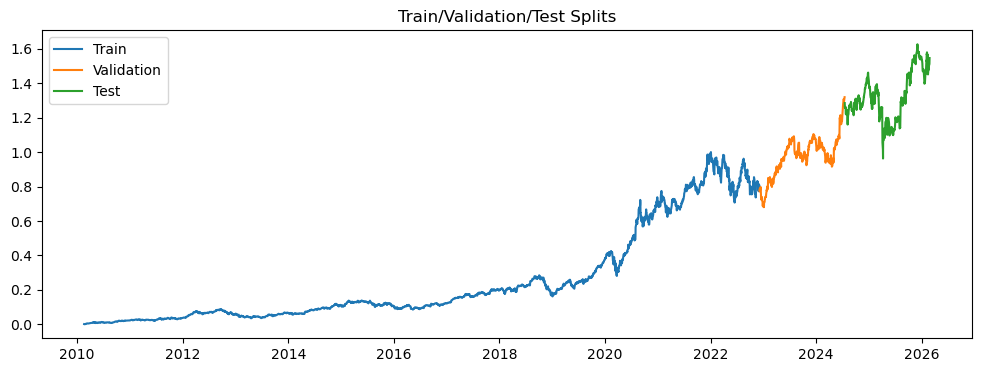

In [16]:
plt.figure(figsize=(12,4))
plt.plot(dates_train, y_train, label='Train')
plt.plot(dates_val, y_val, label='Validation')
plt.plot(dates_test, y_test, label='Test')
plt.legend()
plt.title("Train/Validation/Test Splits")
plt.show()

In [17]:
# PyTorch tensors and GPU setup

device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train, dtype=torch.float32, device=device).unsqueeze(1)
X_val_t   = torch.tensor(X_val, dtype=torch.float32, device=device)
y_val_t   = torch.tensor(y_val, dtype=torch.float32, device=device).unsqueeze(1)
X_test_t  = torch.tensor(X_test, dtype=torch.float32, device=device)
y_test_t  = torch.tensor(y_test, dtype=torch.float32, device=device).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64)

Using device: mps


## Baseline LSTM Model

In [18]:
# Define LSTM model

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, dense_size=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.fc1 = nn.Linear(hidden_size, dense_size)
        self.fc2 = nn.Linear(dense_size, dense_size)
        self.fc3 = nn.Linear(dense_size, 1)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # Last timestep
        out = torch.relu(self.fc1(out))
        out = torch.relu(self.fc2(out))
        out = self.fc3(out)
        return out

model = LSTMModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [19]:
epochs = 50
train_losses = []
val_losses = []

for epoch in range(1, epochs+1):
    # Training
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)
    
    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

Epoch 1/50 - Train Loss: 0.0840, Val Loss: 0.6607
Epoch 2/50 - Train Loss: 0.0761, Val Loss: 0.5847
Epoch 3/50 - Train Loss: 0.0678, Val Loss: 0.4235
Epoch 4/50 - Train Loss: 0.0308, Val Loss: 0.0208
Epoch 5/50 - Train Loss: 0.0066, Val Loss: 0.0311
Epoch 6/50 - Train Loss: 0.0045, Val Loss: 0.0395
Epoch 7/50 - Train Loss: 0.0035, Val Loss: 0.0420
Epoch 8/50 - Train Loss: 0.0028, Val Loss: 0.0343
Epoch 9/50 - Train Loss: 0.0022, Val Loss: 0.0300
Epoch 10/50 - Train Loss: 0.0018, Val Loss: 0.0268
Epoch 11/50 - Train Loss: 0.0015, Val Loss: 0.0227
Epoch 12/50 - Train Loss: 0.0012, Val Loss: 0.0211
Epoch 13/50 - Train Loss: 0.0010, Val Loss: 0.0165
Epoch 14/50 - Train Loss: 0.0009, Val Loss: 0.0138
Epoch 15/50 - Train Loss: 0.0008, Val Loss: 0.0162
Epoch 16/50 - Train Loss: 0.0007, Val Loss: 0.0119
Epoch 17/50 - Train Loss: 0.0006, Val Loss: 0.0112
Epoch 18/50 - Train Loss: 0.0006, Val Loss: 0.0114
Epoch 19/50 - Train Loss: 0.0006, Val Loss: 0.0106
Epoch 20/50 - Train Loss: 0.0005, Val Lo

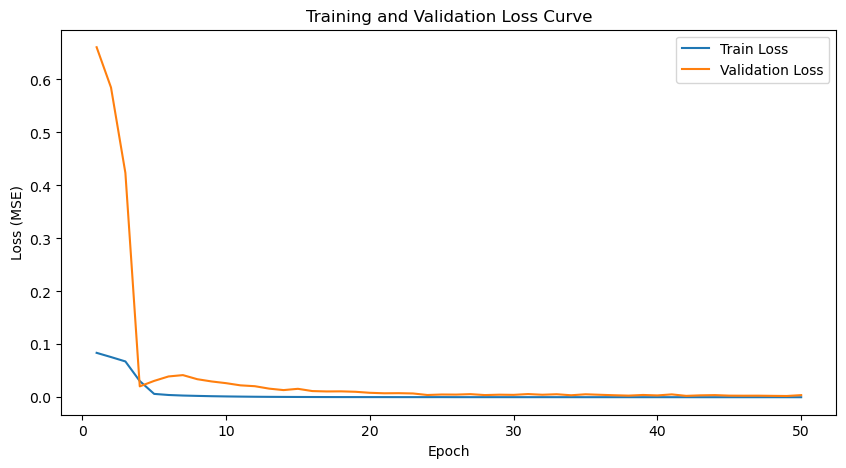

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training and Validation Loss Curve")
plt.legend()
plt.show()

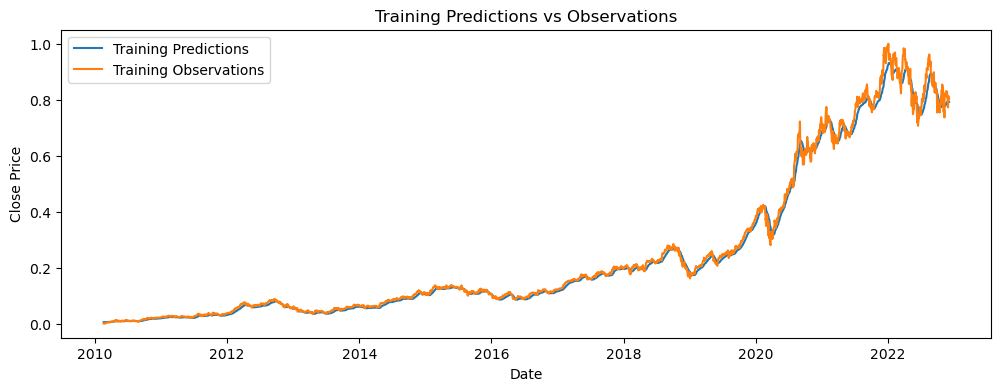

In [21]:
model.eval()

with torch.no_grad():
    train_preds = model(torch.tensor(X_train, dtype=torch.float32, device=device))
    train_preds = train_preds.cpu().numpy().flatten() 

plt.figure(figsize=(12, 4))
plt.plot(dates_train, train_preds, label='Training Predictions')
plt.plot(dates_train, y_train, label='Training Observations')
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Training Predictions vs Observations")
plt.legend()
plt.show()


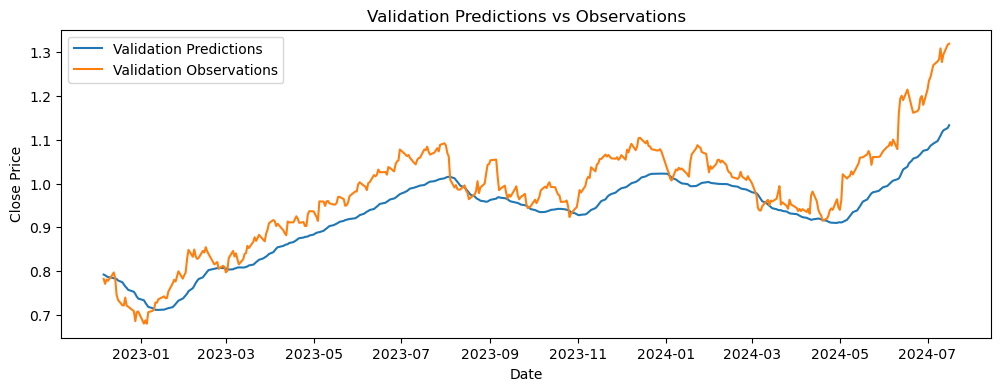

In [22]:
model.eval()

with torch.no_grad():
    val_preds = model(torch.tensor(X_val, dtype=torch.float32, device=device))
    val_preds = val_preds.cpu().numpy().flatten() 

plt.figure(figsize=(12, 4))
plt.plot(dates_val, val_preds, label='Validation Predictions')
plt.plot(dates_val, y_val, label='Validation Observations')
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Validation Predictions vs Observations")
plt.legend()
plt.show()


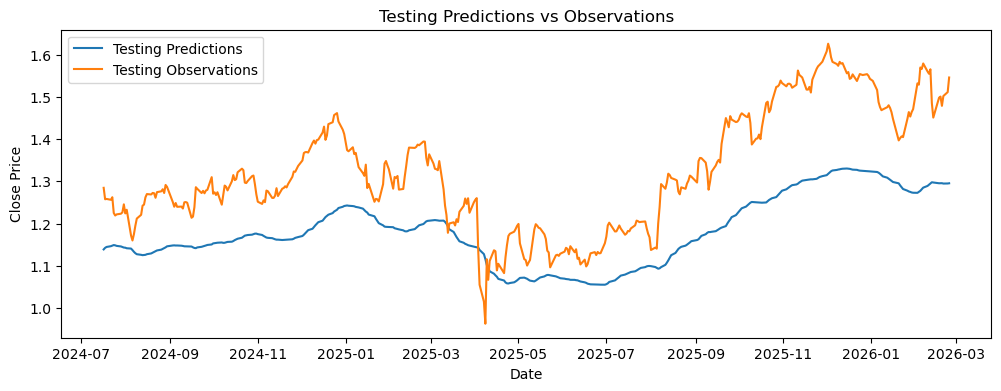

In [23]:
model.eval()

with torch.no_grad():
    test_preds = model(torch.tensor(X_test, dtype=torch.float32, device=device))
    test_preds = test_preds.cpu().numpy().flatten()

plt.figure(figsize=(12, 4))
plt.plot(dates_test, test_preds, label='Testing Predictions')
plt.plot(dates_test, y_test, label='Testing Observations')
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Testing Predictions vs Observations")
plt.legend()
plt.show()


In [24]:
model.eval()

with torch.no_grad():
    train_preds_t = model(X_train_t)
    val_preds_t   = model(X_val_t)
    test_preds_t  = model(X_test_t)

    mse_loss = nn.MSELoss()(test_preds_t, y_test_t).item()
    mae_loss = nn.L1Loss()(test_preds_t, y_test_t).item()

train_preds = train_preds_t.cpu().numpy()
val_preds   = val_preds_t.cpu().numpy()
test_preds  = test_preds_t.cpu().numpy()

train_preds = scaler_y.inverse_transform(train_preds)
val_preds   = scaler_y.inverse_transform(val_preds)
test_preds  = scaler_y.inverse_transform(test_preds)

y_train_inv = scaler_y.inverse_transform(y_train.reshape(-1,1))
y_val_inv   = scaler_y.inverse_transform(y_val.reshape(-1,1))
y_test_inv  = scaler_y.inverse_transform(y_test.reshape(-1,1))

print(f"Test MSE (scaled): {mse_loss:.4f}")
print(f"Test MAE (scaled): {mae_loss:.4f}")

test_mae_price = np.mean(np.abs(test_preds - y_test_inv))
print(f"Test MAE (actual price units): {test_mae_price:.4f}")


Test MSE (scaled): 0.0245
Test MAE (scaled): 0.1420
Test MAE (actual price units): 24.4573


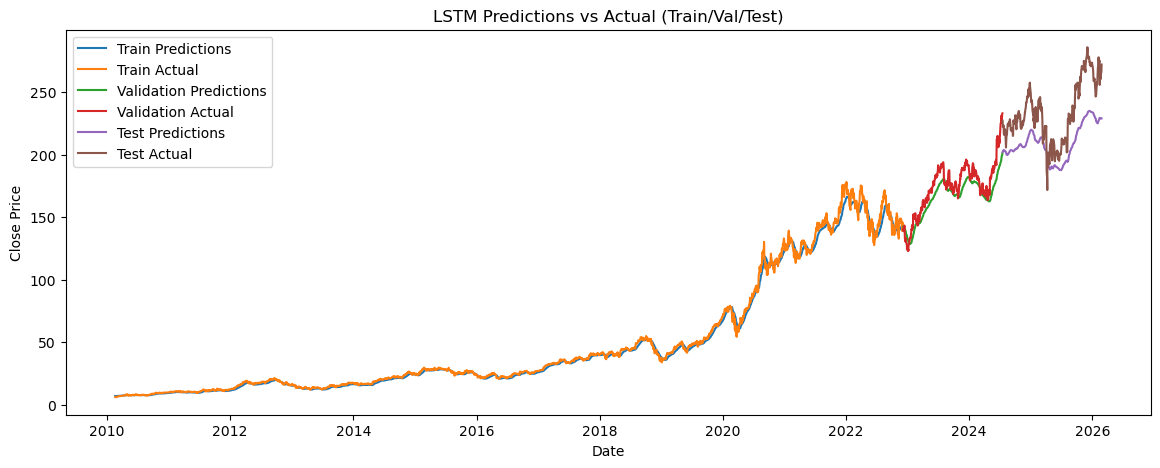

In [25]:
plt.figure(figsize=(14,5))

plt.plot(dates_train, train_preds, label='Train Predictions')
plt.plot(dates_train, y_train_inv, label='Train Actual')

plt.plot(dates_val, val_preds, label='Validation Predictions')
plt.plot(dates_val, y_val_inv, label='Validation Actual')

plt.plot(dates_test, test_preds, label='Test Predictions')
plt.plot(dates_test, y_test_inv, label='Test Actual')

plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("LSTM Predictions vs Actual (Train/Val/Test)")
plt.legend()
plt.show()


# Updated / Enhanced LSTM Model

In [26]:
# Updated/Improved LSTM model

class EnhancedLSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=5, dense_size=64, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers,
                            batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size, dense_size)
        self.fc2 = nn.Linear(dense_size, dense_size)
        self.fc3 = nn.Linear(dense_size, 1)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # Last timestep
        out = self.dropout(out)
        out = torch.relu(self.fc1(out))
        out = torch.relu(self.fc2(out))
        out = self.fc3(out)
        return out

enhanced_model = EnhancedLSTMModel().to(device)
enh_criterion = nn.MSELoss()
enh_optimizer = torch.optim.Adam(enhanced_model.parameters(), lr=0.0005)

In [27]:
epochs = 100
e_train_losses = []
e_val_losses = []

for epoch in range(1, epochs+1):
    # Training
    enhanced_model.train()
    train_loss = 0
    for xb, yb in train_loader:
        enh_optimizer.zero_grad()
        preds = enhanced_model(xb)
        loss = enh_criterion(preds, yb)
        loss.backward()
        enh_optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)
    e_train_losses.append(train_loss)
    
    # Validation
    enhanced_model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = enhanced_model(xb)
            loss = enh_criterion(preds, yb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(val_loader.dataset)
    e_val_losses.append(val_loss)
    
    print(f"Epoch {epoch}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

Epoch 1/100 - Train Loss: 0.0662, Val Loss: 0.0287
Epoch 2/100 - Train Loss: 0.0080, Val Loss: 0.0628
Epoch 3/100 - Train Loss: 0.0027, Val Loss: 0.0268
Epoch 4/100 - Train Loss: 0.0016, Val Loss: 0.0304
Epoch 5/100 - Train Loss: 0.0015, Val Loss: 0.0189
Epoch 6/100 - Train Loss: 0.0011, Val Loss: 0.0189
Epoch 7/100 - Train Loss: 0.0013, Val Loss: 0.0332
Epoch 8/100 - Train Loss: 0.0010, Val Loss: 0.0241
Epoch 9/100 - Train Loss: 0.0009, Val Loss: 0.0126
Epoch 10/100 - Train Loss: 0.0009, Val Loss: 0.0139
Epoch 11/100 - Train Loss: 0.0010, Val Loss: 0.0111
Epoch 12/100 - Train Loss: 0.0009, Val Loss: 0.0106
Epoch 13/100 - Train Loss: 0.0007, Val Loss: 0.0075
Epoch 14/100 - Train Loss: 0.0008, Val Loss: 0.0149
Epoch 15/100 - Train Loss: 0.0010, Val Loss: 0.0076
Epoch 16/100 - Train Loss: 0.0007, Val Loss: 0.0110
Epoch 17/100 - Train Loss: 0.0008, Val Loss: 0.0081
Epoch 18/100 - Train Loss: 0.0006, Val Loss: 0.0057
Epoch 19/100 - Train Loss: 0.0005, Val Loss: 0.0036
Epoch 20/100 - Train 

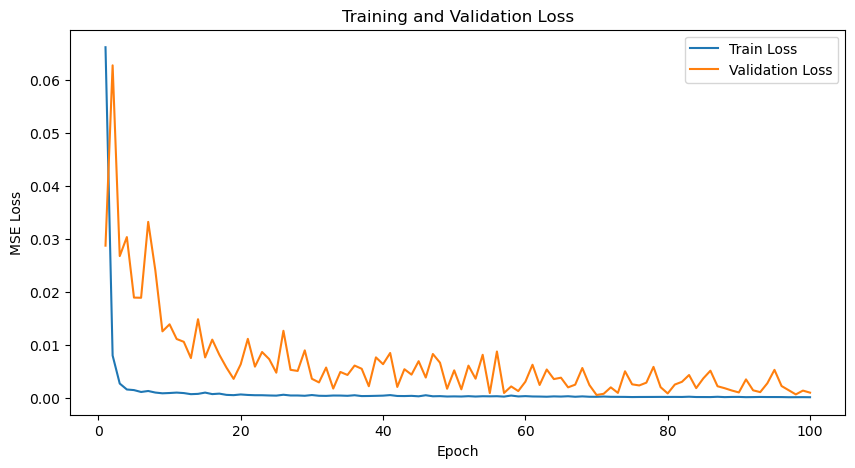

In [28]:
plt.figure(figsize=(10,5))
plt.plot(range(1, epochs+1), e_train_losses, label='Train Loss')
plt.plot(range(1, epochs+1), e_val_losses, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [29]:
enhanced_model.eval()

with torch.no_grad():
    train_preds_scaled = enhanced_model(torch.tensor(X_train, dtype=torch.float32, device=device)).detach().cpu().numpy().flatten()
    val_preds_scaled   = enhanced_model(torch.tensor(X_val, dtype=torch.float32, device=device)).detach().cpu().numpy().flatten()
    test_preds_scaled  = enhanced_model(torch.tensor(X_test, dtype=torch.float32, device=device)).detach().cpu().numpy().flatten()

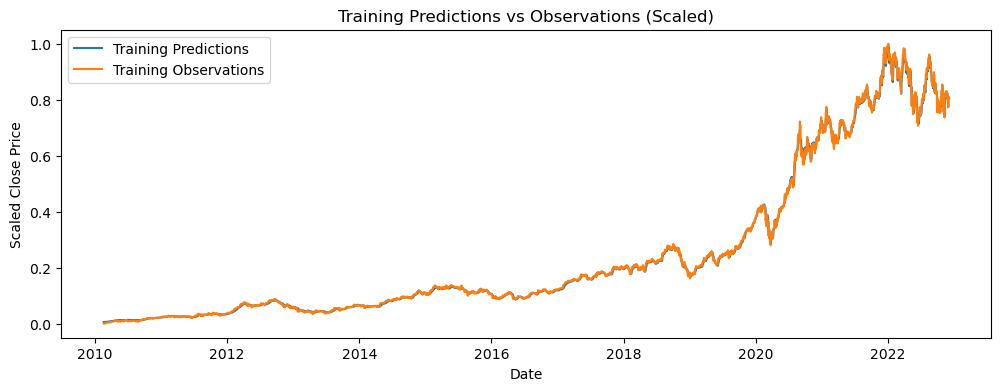

In [30]:
plt.figure(figsize=(12, 4))
plt.plot(dates_train, train_preds_scaled, label='Training Predictions')
plt.plot(dates_train, y_train, label='Training Observations')
plt.xlabel("Date")
plt.ylabel("Scaled Close Price")
plt.title("Training Predictions vs Observations (Scaled)")
plt.legend()
plt.show()

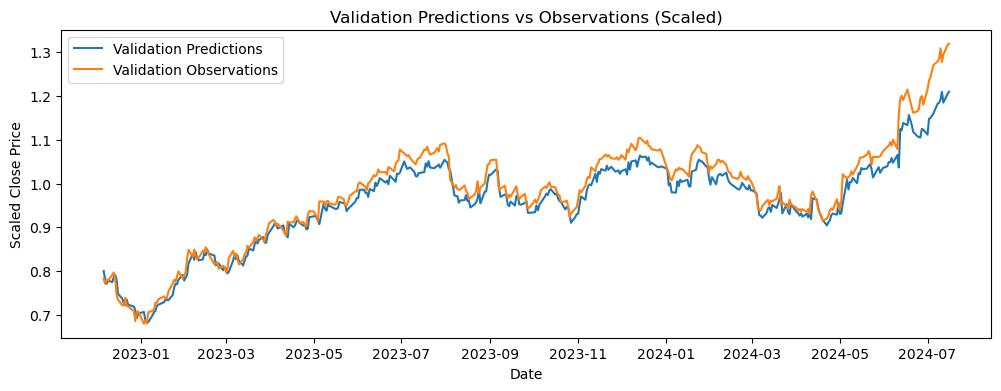

In [31]:
plt.figure(figsize=(12, 4))
plt.plot(dates_val, val_preds_scaled, label='Validation Predictions')
plt.plot(dates_val, y_val, label='Validation Observations')
plt.xlabel("Date")
plt.ylabel("Scaled Close Price")
plt.title("Validation Predictions vs Observations (Scaled)")
plt.legend()
plt.show()

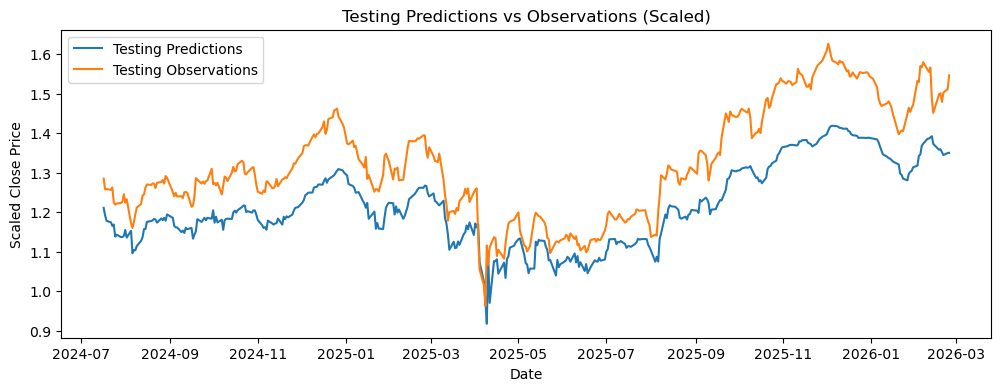

In [32]:
plt.figure(figsize=(12, 4))
plt.plot(dates_test, test_preds_scaled, label='Testing Predictions')
plt.plot(dates_test, y_test, label='Testing Observations')
plt.xlabel("Date")
plt.ylabel("Scaled Close Price")
plt.title("Testing Predictions vs Observations (Scaled)")
plt.legend()
plt.show()

In [33]:
enhanced_model.eval()
with torch.no_grad():
    train_preds_scaled_t = enhanced_model(X_train_t).detach().cpu().numpy()
    val_preds_scaled_t   = enhanced_model(X_val_t).detach().cpu().numpy()
    test_preds_scaled_t  = enhanced_model(X_test_t).detach().cpu().numpy()

train_preds = scaler_y.inverse_transform(train_preds_scaled_t).flatten()
val_preds   = scaler_y.inverse_transform(val_preds_scaled_t).flatten()
test_preds  = scaler_y.inverse_transform(test_preds_scaled_t).flatten()

y_train_inv = scaler_y.inverse_transform(y_train.reshape(-1, 1)).flatten()
y_val_inv   = scaler_y.inverse_transform(y_val.reshape(-1, 1)).flatten()
y_test_inv  = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()


In [34]:
enhanced_model.eval()
with torch.no_grad():
    test_preds_for_metrics = enhanced_model(X_test_t)

    mse_loss = nn.MSELoss()(test_preds_for_metrics, y_test_t).item()
    mae_loss = nn.L1Loss()(test_preds_for_metrics, y_test_t).item()

    test_preds_inv_metrics = scaler_y.inverse_transform(
        test_preds_for_metrics.detach().cpu().numpy()
    ).flatten()

    y_test_inv_metrics = scaler_y.inverse_transform(
        y_test_t.detach().cpu().numpy()
    ).flatten()

print(f"Test MSE (scaled): {mse_loss:.4f}")
print(f"Test MAE (scaled): {mae_loss:.4f}")

test_mae_price = np.mean(np.abs(test_preds_inv_metrics - y_test_inv_metrics))
print(f"Test MAE (actual price units): {test_mae_price:.4f}")


Test MSE (scaled): 0.0133
Test MAE (scaled): 0.1071
Test MAE (actual price units): 18.4434


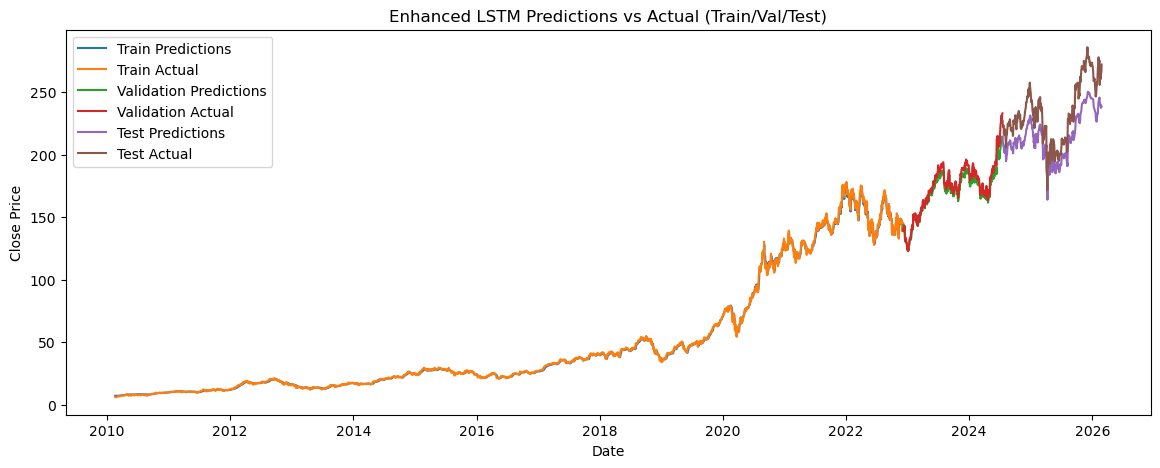

In [35]:
plt.figure(figsize=(14, 5))

plt.plot(dates_train, train_preds, label='Train Predictions')
plt.plot(dates_train, y_train_inv, label='Train Actual')

plt.plot(dates_val, val_preds, label='Validation Predictions')
plt.plot(dates_val, y_val_inv, label='Validation Actual')

plt.plot(dates_test, test_preds, label='Test Predictions')
plt.plot(dates_test, y_test_inv, label='Test Actual')

plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Enhanced LSTM Predictions vs Actual (Train/Val/Test)")
plt.legend()
plt.show()

Baseline — Mean residual: $-24.12, Std: $12.09
Enhanced — Mean residual: $-18.37, Std: $7.53


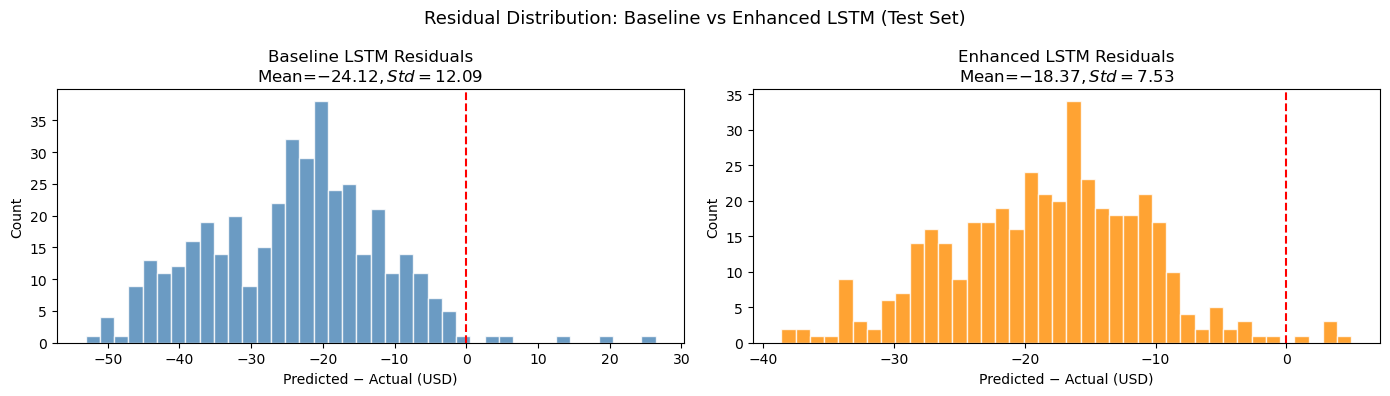

No distributed computing (Spark/HPC) required — dataset ~4,000 rows fits in memory.


In [36]:
# Residual Analysis

model.eval()
enhanced_model.eval()

with torch.no_grad():
    # Baseline
    baseline_out = model(X_test_t).cpu().numpy()
    baseline_usd = scaler_y.inverse_transform(baseline_out)
    
    # Enhanced
    enhanced_out = enhanced_model(X_test_t).cpu().numpy()
    enhanced_usd = scaler_y.inverse_transform(enhanced_out)

y_test_usd_plot = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# Residuals: Predicted - Actual
baseline_residuals = (baseline_usd - y_test_usd_plot).flatten()
enhanced_residuals = (enhanced_usd - y_test_usd_plot).flatten()

print(f"Baseline — Mean residual: ${np.mean(baseline_residuals):.2f}, Std: ${np.std(baseline_residuals):.2f}")
print(f"Enhanced — Mean residual: ${np.mean(enhanced_residuals):.2f}, Std: ${np.std(enhanced_residuals):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(baseline_residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title(f"Baseline LSTM Residuals\nMean=${np.mean(baseline_residuals):.2f}, Std=${np.std(baseline_residuals):.2f}")
axes[0].set_xlabel("Predicted − Actual (USD)")
axes[0].set_ylabel("Count")

axes[1].hist(enhanced_residuals, bins=40, color='darkorange', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title(f"Enhanced LSTM Residuals\nMean=${np.mean(enhanced_residuals):.2f}, Std=${np.std(enhanced_residuals):.2f}")
axes[1].set_xlabel("Predicted − Actual (USD)")
axes[1].set_ylabel("Count")

plt.suptitle("Residual Distribution: Baseline vs Enhanced LSTM (Test Set)", fontsize=13)
plt.tight_layout()
plt.savefig("residual_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

print("No distributed computing (Spark/HPC) required — dataset ~4,000 rows fits in memory.")

In [37]:
# Count trainable parameters in both models

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

baseline_params  = count_parameters(LSTMModel().to('cpu'))
enhanced_params  = count_parameters(EnhancedLSTMModel().to('cpu'))
ratio            = enhanced_params / baseline_params

print(f"Baseline LSTM   — Trainable parameters: {baseline_params:,}")
print(f"Enhanced LSTM   — Trainable parameters: {enhanced_params:,}")
print(f"Capacity ratio  — Enhanced is {ratio:.1f}× larger than baseline")
print(f"Dropout(0.2) regularizes the {enhanced_params:,}-parameter Enhanced LSTM to prevent overfitting.")

Baseline LSTM   — Trainable parameters: 20,321
Enhanced LSTM   — Trainable parameters: 607,937
Capacity ratio  — Enhanced is 29.9× larger than baseline
Dropout(0.2) regularizes the 607,937-parameter Enhanced LSTM to prevent overfitting.
